# Distributed GBT Regression Model Training
VoltStream: Smart Grid Predictive Analytics Pipeline.

# Part 1: Data Loading, Transformation and Exploration <a class="anchor" name="part-1"></a>
## 1.1 Data Loading
In this section, you must load the given datasets into PySpark DataFrames and use DataFrame functions to process the data. For plotting, various visualisation packages can be used, but please ensure that you have included instructions to install the additional packages and that the installation will be successful in the provided Docker container (in case your marker needs to clear the notebook and rerun it).

### 1.1.1 Data Loading <a class="anchor" name="1.1"></a>
1.1.1 Write the code to create a SparkSession. For creating the SparkSession, you need to use a SparkConf object to configure the Spark app with a proper application name, to ensure the maximum partition size does not exceed 32MB, and to run locally with all CPU cores on your machine

In [1]:
from pyspark import SparkConf
from pyspark.sql import SparkSession

# 1. Create a SparkConf object to hold the configuration
spark_conf = SparkConf() \
    .setAppName("VoltStream Model Training") \
    .set("spark.sql.files.maxPartitionBytes", "32m") \
    .setMaster("local[*]")

# 2. Create the SparkSession using the SparkConf object
spark = SparkSession.builder \
    .config(conf=spark_conf) \
    .getOrCreate()

print(spark)

1.1.2 Write code to define the schemas for the datasets, following the data types suggested in the metadata file. 

In [2]:
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, DoubleType, TimestampType

# Define the schema for meter readings to ensure data types are correct upon loading.
# This prevents potential errors from Spark's schema inference.
meter_schema = StructType([
    StructField("building_id", IntegerType(), True),
    StructField("meter_type", StringType(), True),      # StringType is safer for single characters.
    StructField("ts", TimestampType(), True),
    StructField("value", DoubleType(), True),
    StructField("row_id", IntegerType(), True)
])

# Define the schema for the building information.
# Explicitly defining the schema improves performance and data consistency.
building_schema = StructType([
    StructField("site_id", IntegerType(), True),
    StructField("building_id", IntegerType(), True),
    StructField("primary_use", StringType(), True),
    StructField("square_feet", IntegerType(), True),
    StructField("floor_count", IntegerType(), True),
    StructField("row_id", IntegerType(), True),
    StructField("year_built", IntegerType(), True),
    # Latent features are included as they might hold predictive value.
    StructField("latent_y", DoubleType(), True),
    StructField("latent_s", DoubleType(), True),
    StructField("latent_r", DoubleType(), True)
])

# Define the schema for the weather data.
# This ensures that numerical fields are not accidentally read as strings.
weather_schema = StructType([
    StructField("site_id", IntegerType(), True),
    StructField("timestamp", TimestampType(), True),
    StructField("air_temperature", DoubleType(), True),
    StructField("cloud_coverage", DoubleType(), True),
    StructField("dew_temperature", DoubleType(), True),
    StructField("sea_level_pressure", DoubleType(), True),
    StructField("wind_direction", DoubleType(), True),
    StructField("wind_speed", DoubleType(), True)
])

1.1.3 Using your schemas, load the CSV files into separate data frames. Print the schemas of all data frames. 

In [3]:
# Load the datasets using the predefined schemas.
# This ensures that data types are enforced upon reading the files.
building_df = spark.read.csv("../data/building_information.csv", header=True, schema=building_schema)
weather_df = spark.read.csv("../data/weather.csv", header=True, schema=weather_schema)
meter_df = spark.read.csv("../data/meters.csv", header=True, schema=meter_schema)

# --- Verification Step ---
# Display the schema and a few rows of each DataFrame to confirm they loaded correctly.

print("--- Verifying building_df ---")
building_df.printSchema()
building_df.show(5)

print("\n--- Verifying weather_df ---")
weather_df.printSchema()
weather_df.show(5)

print("\n--- Verifying meter_df ---")
meter_df.printSchema()
meter_df.show(5)

--- Verifying building_df ---
root
 |-- site_id: integer (nullable = true)
 |-- building_id: integer (nullable = true)
 |-- primary_use: string (nullable = true)
 |-- square_feet: integer (nullable = true)
 |-- floor_count: integer (nullable = true)
 |-- row_id: integer (nullable = true)
 |-- year_built: integer (nullable = true)
 |-- latent_y: double (nullable = true)
 |-- latent_s: double (nullable = true)
 |-- latent_r: double (nullable = true)

+-------+-----------+-------------+-----------+-----------+------+----------+--------+---------+--------+
|site_id|building_id|  primary_use|square_feet|floor_count|row_id|year_built|latent_y| latent_s|latent_r|
+-------+-----------+-------------+-----------+-----------+------+----------+--------+---------+--------+
|      2|        165|    Warehouse|       3877|          1|   166|      1982|    18.0|3.5884957|     3.0|
|      2|        229|    Education|     140092|          1|   230|      1999|     1.0|5.1464133|     3.0|
|      1|        

In [4]:
from pyspark.sql.functions import window, sum as _sum

# Aggregate the hourly meter readings into 6-hour intervals for each building.
# This reduces the data's granularity to create the target variable for our prediction model.
meter_df_agg = meter_df.groupBy(
    "building_id",
    window("ts", "6 hours")  # Creates tumbling (non-overlapping) 6-hour windows.
).agg(
    _sum("value").alias("total_energy_consumption")  # Sum the consumption values within each window.
)

# Display the resulting aggregated data to verify the transformation.
print("--- Aggregated Meter Readings (6-hour intervals) ---")
meter_df_agg.show()

--- Aggregated Meter Readings (6-hour intervals) ---
+-----------+--------------------+------------------------+
|building_id|              window|total_energy_consumption|
+-----------+--------------------+------------------------+
|        258|{2022-01-01 12:00...|      242.17629999999997|
|        928|{2022-01-01 12:00...|                4054.541|
|        996|{2022-01-01 12:00...|               2030.5453|
|       1168|{2022-01-02 12:00...|             308836.8331|
|        920|{2022-01-02 18:00...|       576.0677000000001|
|       1342|{2022-01-02 18:00...|                903.0262|
|       1388|{2022-01-03 06:00...|                478.5848|
|       1211|{2022-01-03 18:00...|               12046.066|
|        801|{2022-01-04 00:00...|       48967.21000000001|
|       1312|{2022-01-04 00:00...|               2476.4169|
|       1088|{2022-01-04 06:00...|             153586.5986|
|       1169|{2022-01-04 12:00...|               31927.523|
|       1355|{2022-01-04 12:00...|       6878.9

In the weather dataset, there are some missing values (null or empty strings). It may lower the quality of our model. Imputation is a way to deal with those missing values. Imputation is the process of replacing missing values in a dataset with substituted, or "imputed," values. It's a way to handle gaps in your data so that you can still analyse it effectively without having to delete incomplete records.  
1.2.2 Refer to the Spark MLLib imputation API and fill in the missing values in the weather dataset. You can use mean values as the strategy.  https://spark.apache.org/docs/3.5.5/api/python/reference/api/pyspark.ml.feature.Imputer.html

In [5]:
from pyspark.ml.feature import Imputer
from pyspark.sql.functions import col, count, when

# Impute missing values in the weather data to improve model quality.
# Using the mean is a simple yet effective strategy for numerical data.

# A list of the weather-related columns that contain null values.
impute_cols = [
    "air_temperature",
    "cloud_coverage",
    "dew_temperature",
    "sea_level_pressure",
    "wind_direction",
    "wind_speed"
]

# Configure the Imputer to calculate the mean for each specified column
# and create new columns with the imputed values.
imputer = Imputer(
    inputCols=impute_cols,
    outputCols=[f"{c}_imputed" for c in impute_cols]
).setStrategy("mean")

# Fit the imputer on the dataset to calculate the mean of each column.
imputer_model = imputer.fit(weather_df)

# Apply the trained imputer to fill in the null values.
weather_df_imputed = imputer_model.transform(weather_df)

# Clean up the DataFrame by replacing the original columns with the imputed ones.
weather_df_cleaned = weather_df_imputed
for c in impute_cols:
    weather_df_cleaned = weather_df_cleaned.drop(c).withColumnRenamed(f"{c}_imputed", c)

# Verify that the imputation was successful by counting nulls in the cleaned DataFrame.
# The result should show zero nulls for all imputed columns.
print("--- Null counts in weather_df after imputation ---")
weather_df_cleaned.select([count(when(col(c).isNull(), c)).alias(c) for c in impute_cols]).show()

print("\n--- Cleaned Weather Data ---")
weather_df_cleaned.show()

--- Null counts in weather_df after imputation ---
+---------------+--------------+---------------+------------------+--------------+----------+
|air_temperature|cloud_coverage|dew_temperature|sea_level_pressure|wind_direction|wind_speed|
+---------------+--------------+---------------+------------------+--------------+----------+
|              0|             0|              0|                 0|             0|         0|
+---------------+--------------+---------------+------------------+--------------+----------+


--- Cleaned Weather Data ---
+-------+-------------------+---------------+------------------+---------------+------------------+--------------+----------+
|site_id|          timestamp|air_temperature|    cloud_coverage|dew_temperature|sea_level_pressure|wind_direction|wind_speed|
+-------+-------------------+---------------+------------------+---------------+------------------+--------------+----------+
|      0|2022-01-01 22:00:00|           26.7|2.1493059490084985|      

In [6]:
from pyspark.sql.functions import month, col

# Before creating seasonal features, verify that the data is complete for a sample site.
# This check ensures that we have data for all 12 months for site 0,
# which is necessary for a fair comparison of monthly average temperatures.
weather_df_cleaned.filter(col("site_id")==0) \
    .select(month("timestamp").alias("m")) \
    .groupBy("m").count().orderBy("m").show(100)

+---+-----+
|  m|count|
+---+-----+
|  1|  744|
|  2|  696|
|  3|  744|
|  4|  720|
|  5|  744|
|  6|  720|
|  7|  744|
|  8|  744|
|  9|  720|
| 10|  744|
| 11|  720|
| 12|  744|
+---+-----+



We know that different seasons may affect energy consumption—for instance, a heater in winter and a cooler in summer. Extracting peak seasons (summer and winter) or off-peak seasons (Spring and Autumn) might be more useful than directly using the month as numerical values.   
1.2.3 The dataset has 16 sites in total, whose locations may span across different countries. Add a column (peak/off-peak) to the weather data frame based on the average air temperature. The top 3 hottest months and the 3 coldest months are considered “peak”, and the rest of the year is considered “off-peak”. 

In [7]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

# This multi-step process engineers a 'season_type' feature ('peak' or 'off-peak')
# by identifying the three hottest and three coldest months for each site individually.

# Use an alias for the cleaned weather DataFrame for more readable code.
w = weather_df_cleaned.alias("w")

# 1. First, calculate the average air temperature for each month at each site.
# This will be the basis for ranking the seasons.
monthly_avg = (
    w.withColumn("month", F.month("w.timestamp"))
     .groupBy("w.site_id", "month")
     .agg(F.avg("w.air_temperature").alias("avg_temp"))
     .alias("ma")
)

# 2. Use window functions to rank the months for each site.
# This allows us to find the top 3 hottest and coldest months per site.
win_cold = Window.partitionBy("ma.site_id").orderBy(F.col("avg_temp").asc())
win_hot  = Window.partitionBy("ma.site_id").orderBy(F.col("avg_temp").desc())

# Get the 3 coldest months for each site.
cold3 = (
    monthly_avg
    .withColumn("cold_rank", F.row_number().over(win_cold))
    .filter(F.col("cold_rank") <= 3)
    .select(F.col("ma.site_id").alias("site_id"), "month")
)

# Get the 3 hottest months for each site.
hot3 = (
    monthly_avg
    .withColumn("hot_rank", F.row_number().over(win_hot))
    .filter(F.col("hot_rank") <= 3)
    .select(F.col("ma.site_id").alias("site_id"), "month")
)

# Combine the hot and cold months into a single DataFrame of peak season months.
peak_months = (
    cold3.unionByName(hot3)
         .dropDuplicates(["site_id", "month"])
         .alias("pm")
)

# 3. Join the peak months back to the main weather data to create the 'season_type' column.
# A left join ensures we keep all original weather records.
weather_with_season = (
    w.join(
        peak_months,
        on=(
            (F.col("w.site_id") == F.col("pm.site_id")) &
            (F.month(F.col("w.timestamp")) == F.col("pm.month"))
        ),
        how="left"
    )
    # If a month is in 'peak_months', label it as 'peak', otherwise 'off-peak'.
    .withColumn(
        "season_type",
        F.when(F.col("pm.month").isNotNull(), F.lit("peak")).otherwise(F.lit("off-peak"))
    )
    # Drop the temporary columns used for the join.
    .drop("pm.site_id", "pm.month")
)

# Project a clean final DataFrame. This is good practice for managing schema.
weather_with_season = weather_with_season.select(
    "w.timestamp", "w.site_id",
    "w.air_temperature", "w.cloud_coverage", "w.dew_temperature",
    "w.sea_level_pressure", "w.wind_direction", "w.wind_speed",
    "season_type"
)

In [8]:
# --- VALIDATION ---

# 0. Check the foundational data for the ranking.
# By inspecting the average temperatures for a single site, we can manually verify
# that the subsequent ranking of hottest/coldest months will be based on correct data.
print("--- Validation 0: Average Monthly Temperature for Site 0 ---")
monthly_avg.filter(F.col("site_id") == 0).orderBy("month").show()


# 1. Confirm that both 'peak' and 'off-peak' labels were applied.
# A simple row count for a single site should show that both categories are present.
print("\n--- Validation 1: Peak/Off-Peak Row Count for Site 0 ---")
weather_with_season.filter(F.col("site_id")==0) \
    .groupBy("season_type").count().show()

# 2. Verify that there are exactly 6 peak and 6 off-peak months for every site.
# This confirms the core logic of selecting the top 3 hottest and coldest months.
print("\n--- Validation 2: Count of Peak/Off-Peak Months Per Site ---")
months_by_label = (weather_with_season
    .select("site_id", F.month("timestamp").alias("m"), "season_type")
    .dropDuplicates(["site_id","m","season_type"])
    .groupBy("site_id","season_type").count()
)
months_by_label.orderBy("site_id","season_type").show(50)

# 3. Final check to ensure no data was lost.
# Every site should still have data for all 12 distinct months.
print("\n--- Validation 3: Total Distinct Months Per Site ---")
distinct_months = (weather_with_season
    .select("site_id", F.month("timestamp").alias("m"))
    .dropDuplicates()
    .groupBy("site_id").count()
)
distinct_months.orderBy("site_id").show(50)

--- Validation 0: Average Monthly Temperature for Site 0 ---
+-------+-----+------------------+
|site_id|month|          avg_temp|
+-------+-----+------------------+
|      0|    1|14.713110644374733|
|      0|    2| 16.13965517241379|
|      0|    3|  21.2662634408602|
|      0|    4| 22.43125000000002|
|      0|    5|  24.7342741935484|
|      0|    6|27.366388888888856|
|      0|    7| 28.55282258064521|
|      0|    8|27.613575268817204|
|      0|    9|26.871944444444473|
|      0|   10| 24.03817204301075|
|      0|   11|20.055416666666662|
|      0|   12|19.956989247311842|
+-------+-----+------------------+


--- Validation 1: Peak/Off-Peak Row Count for Site 0 ---
+-----------+-----+
|season_type|count|
+-----------+-----+
|   off-peak| 4392|
|       peak| 4392|
+-----------+-----+


--- Validation 2: Count of Peak/Off-Peak Months Per Site ---
+-------+-----------+-----+
|site_id|season_type|count|
+-------+-----------+-----+
|      0|   off-peak|    6|
|      0|       peak|    

Create a data frame with all relevant columns at this stage, we refer to this data frame as feature_df.

In [9]:
from pyspark.sql import functions as F

# --- Aggregate Weather Data into 6-hour Windows ---

# To align with the meter data, the weather features are also aggregated into 6-hour intervals.
# Using an average is a sensible strategy for continuous weather metrics.
weather_df_agg = weather_with_season.groupBy(
    F.col("site_id"),
    F.window(F.col("timestamp"), "6 hours").alias("window")
).agg(
    F.avg("air_temperature").alias("avg_air_temperature"),
    F.avg("cloud_coverage").alias("avg_cloud_coverage"),
    F.avg("dew_temperature").alias("avg_dew_temperature"),
    F.avg("sea_level_pressure").alias("avg_sea_level_pressure"),
    F.avg("wind_direction").alias("avg_wind_direction"),
    F.avg("wind_speed").alias("avg_wind_speed"),
    # The 'season_type' is constant within a window, so taking the first value is sufficient.
    F.first("season_type").alias("season_type")
)


# --- Join the DataFrames to Create the Final feature_df ---

# 1. Join building information with the aggregated meter data on 'building_id'.
# This links the static building features to our target variable (energy consumption).
df_joined_1 = building_df.join(
    meter_df_agg,
    on="building_id",
    how="inner"
)

# 2. Join the result with the aggregated weather data.
# The join is performed on both 'site_id' and the 'window' to ensure
# that each building's energy consumption is matched with the correct weather at that time.
feature_df = df_joined_1.join(
    weather_df_agg,
    on=["site_id", "window"],
    how="inner"
)

# --- Verification Step ---
# Display the schema and a sample of the final feature DataFrame to confirm
# that all data has been combined as expected.
print("--- Final feature_df Schema ---")
feature_df.printSchema()

print("\n--- Final feature_df Sample ---")
feature_df.show(5)

--- Final feature_df Schema ---
root
 |-- site_id: integer (nullable = true)
 |-- window: struct (nullable = false)
 |    |-- start: timestamp (nullable = true)
 |    |-- end: timestamp (nullable = true)
 |-- building_id: integer (nullable = true)
 |-- primary_use: string (nullable = true)
 |-- square_feet: integer (nullable = true)
 |-- floor_count: integer (nullable = true)
 |-- row_id: integer (nullable = true)
 |-- year_built: integer (nullable = true)
 |-- latent_y: double (nullable = true)
 |-- latent_s: double (nullable = true)
 |-- latent_r: double (nullable = true)
 |-- total_energy_consumption: double (nullable = true)
 |-- avg_air_temperature: double (nullable = true)
 |-- avg_cloud_coverage: double (nullable = true)
 |-- avg_dew_temperature: double (nullable = true)
 |-- avg_sea_level_pressure: double (nullable = true)
 |-- avg_wind_direction: double (nullable = true)
 |-- avg_wind_speed: double (nullable = true)
 |-- season_type: string (nullable = true)


--- Final featur

### 1.3 Exploring the Data <a class="anchor" name="1.3"></a>
You can use either the CDA or the EDA method from standard data analysis practices.  
Some ideas for CDA:  
a)	Older building may not be as efficient as new ones, therefore need more energy for cooling/heating. It’s not necessarily true though, if the buildings are built with higher standard or renovated later.  
b)	A multifloored or larger building obviously consumes more energy.  

In [10]:
# --- 1.3.1.a: Statistics for Numeric Columns ---
print("--- Basic Statistics for Numeric Columns ---")
# Select only the numeric columns for the describe() function
numeric_cols = [f.name for f in feature_df.schema.fields if isinstance(f.dataType, (DoubleType, IntegerType))]
feature_df.select(numeric_cols).describe().show()

# --- 1.3.1.b: Statistics for Non-Numeric Columns ---
print("\n--- Top 5 Values for 'primary_use' ---")
feature_df.groupBy("primary_use").count().orderBy(F.col("count").desc()).show(5)

print("\n--- Value Counts for 'season_type' ---")
feature_df.groupBy("season_type").count().show()

--- Basic Statistics for Numeric Columns ---
+-------+-----------------+------------------+------------------+------------------+------------------+------------------+------------------+-----------------+------------------+------------------------+-------------------+------------------+-------------------+----------------------+------------------+------------------+
|summary|          site_id|       building_id|       square_feet|       floor_count|            row_id|        year_built|          latent_y|         latent_s|          latent_r|total_energy_consumption|avg_air_temperature|avg_cloud_coverage|avg_dew_temperature|avg_sea_level_pressure|avg_wind_direction|    avg_wind_speed|
+-------+-----------------+------------------+------------------+------------------+------------------+------------------+------------------+-----------------+------------------+------------------------+-------------------+------------------+-------------------+----------------------+------------------+---

2.	Explore the dataframe and write code to present two plots of multivariate analysis, describe your plots and discuss the findings from the plots. (5% each).  
○	150 words max for each plot’s description and discussion.  
○	Note: In the building metadata table, there are some latent columns (data that may or may not be helpful, their meanings is unknown due to privacy and data security concerns).  
○	Feel free to use any plotting libraries: matplotlib, seabon, plotly, etc. You can refer to https://samplecode.link  


In [11]:
# Import plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# It's a good practice to sample the data before collecting it to the driver for plotting
# to avoid memory issues. Let's take a 1% sample.
sample_pdf = feature_df.sample(withReplacement=False, fraction=0.01, seed=2025).toPandas()

# Set plot style
sns.set(style="whitegrid")

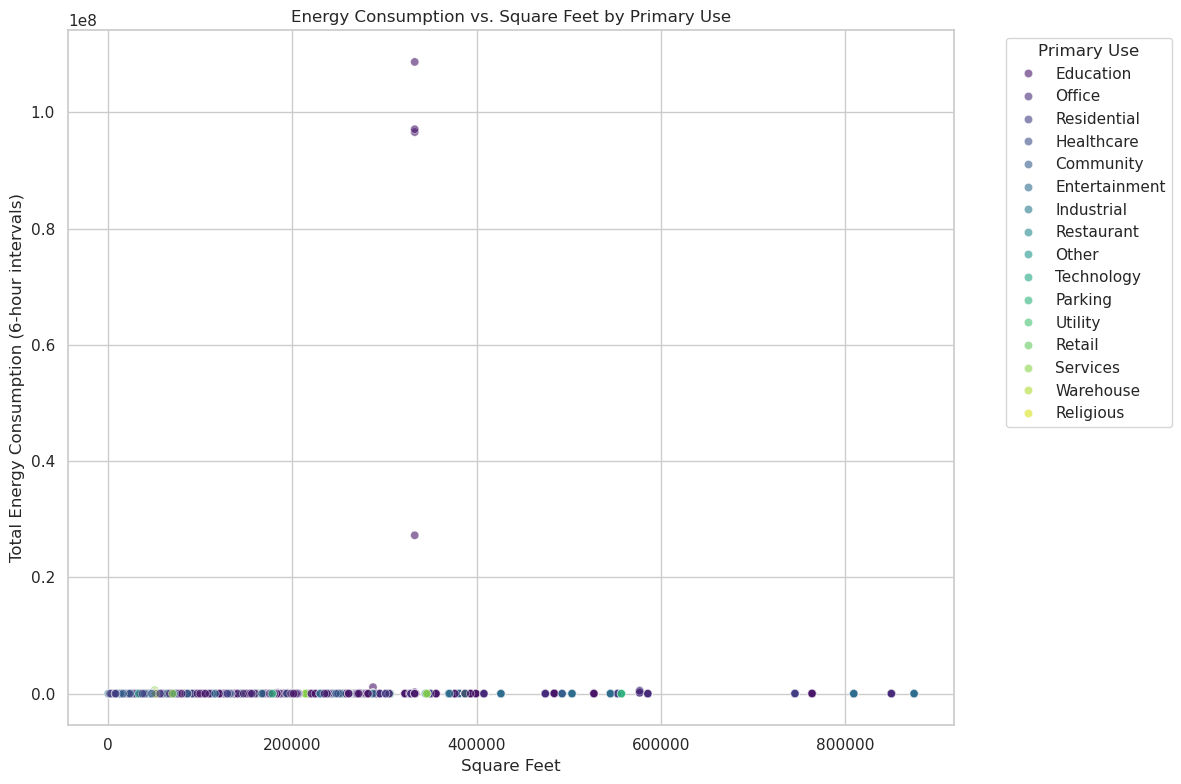

In [12]:
# --- Plot 1: square_feet vs total_energy_consumption ---
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=sample_pdf,
    x='square_feet',
    y='total_energy_consumption',
    hue='primary_use',  # Color points by the building's primary use
    alpha=0.6,
    palette='viridis'
)
plt.title('Energy Consumption vs. Square Feet by Primary Use')
plt.xlabel('Square Feet')
plt.ylabel('Total Energy Consumption (6-hour intervals)')
plt.ticklabel_format(style='plain', axis='x') # Disable scientific notation for x-axis
plt.legend(title='Primary Use', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

###### Findings from Plot 1

The plot confirms the initial hypothesis that larger buildings tend to consume more energy, as shown by the general upward trend. However, the relationship is not strictly linear, and there is significant variance in energy consumption, even among buildings of similar size.

The primary_use of the building is a key factor. For instance, Education and Office buildings, which often have high occupancy and consistent operational hours, show a clearer positive correlation between size and energy use. In contrast, other categories like Entertainment and Residential show a wider spread, suggesting that other factors beyond just size, such as specific equipment or occupancy patterns, play a more significant role in their energy consumption. This insight is valuable for feature engineering and model building, as it highlights the importance of including primary_use as a predictive feature.

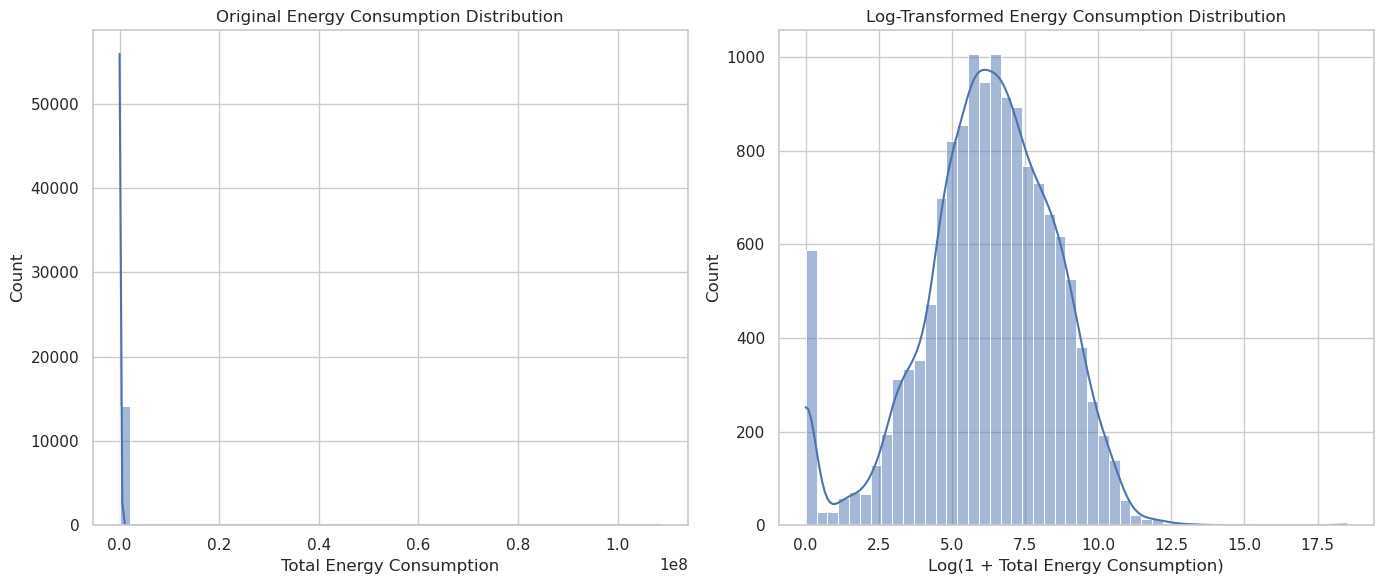

--- Value Counts for Cleaned 'primary_use' ---
+-------------------+------+
|primary_use_cleaned| count|
+-------------------+------+
|          Education|524501|
|             Office|262856|
|      Entertainment|182547|
|          Community|168424|
|        Residential|156612|
|              Other|127566|
+-------------------+------+



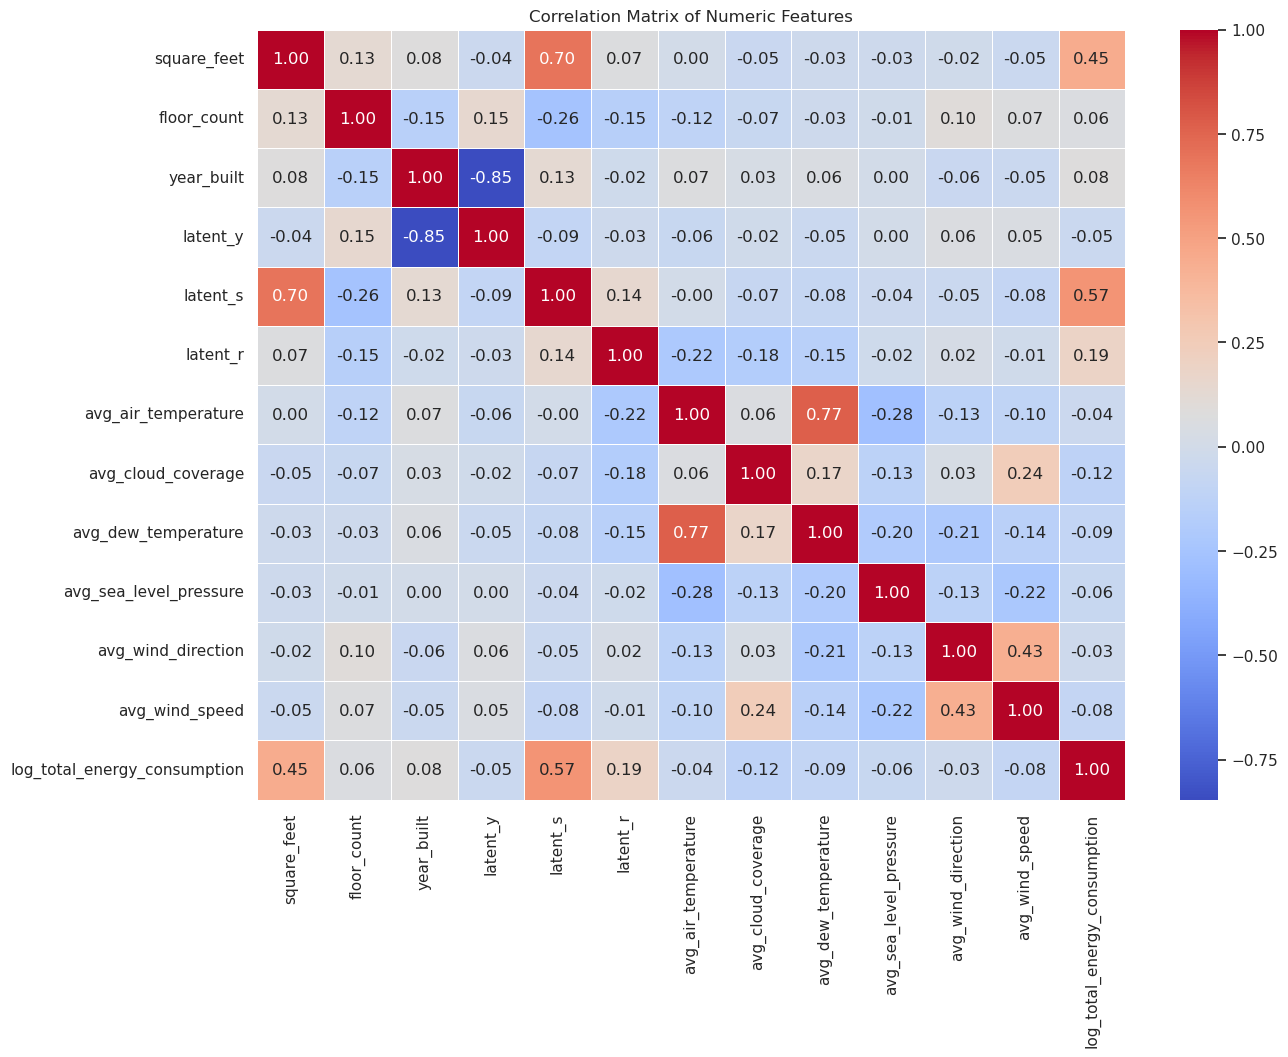

In [15]:
from pyspark.sql.functions import log1p, col, when, lit
from pyspark.ml.stat import Correlation
from pyspark.ml.feature import VectorAssembler
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# --- 1. Log Transform the Target Variable ---

# Apply log1p transformation to handle the skewness and zero values
feature_df_transformed = feature_df.withColumn(
    "log_total_energy_consumption",
    log1p(col("total_energy_consumption"))
)

# --- Visualize the Transformation ---

# Collect the original and transformed data for plotting
energy_data_pdf = feature_df_transformed.select(
    "total_energy_consumption",
    "log_total_energy_consumption"
).sample(0.01, seed=2025).toPandas()

# Create histograms
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.histplot(energy_data_pdf['total_energy_consumption'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Original Energy Consumption Distribution')
axes[0].set_xlabel('Total Energy Consumption')

sns.histplot(energy_data_pdf['log_total_energy_consumption'], bins=50, kde=True, ax=axes[1])
axes[1].set_title('Log-Transformed Energy Consumption Distribution')
axes[1].set_xlabel('Log(1 + Total Energy Consumption)')
plt.tight_layout()
plt.show()


# --- 2. Handle Long-Tail Categorical Features ('primary_use') ---

# Identify the top 5 most frequent categories
top_uses = [
    row['primary_use'] for row in feature_df_transformed.groupBy('primary_use')
    .count().orderBy(col('count').desc()).limit(5).collect()
]

# Group rare categories into "Other"
feature_df_cleaned = feature_df_transformed.withColumn(
    "primary_use_cleaned",
    when(col("primary_use").isin(top_uses), col("primary_use")).otherwise(lit("Other"))
)

print("--- Value Counts for Cleaned 'primary_use' ---")
feature_df_cleaned.groupBy("primary_use_cleaned").count().orderBy(col('count').desc()).show()


# --- 3. Compute and Visualize Correlation Matrix ---

# Select only the numeric features for correlation analysis
numeric_cols_for_corr = [
    'square_feet', 'floor_count', 'year_built',
    'latent_y', 'latent_s', 'latent_r',
    'avg_air_temperature', 'avg_cloud_coverage', 'avg_dew_temperature',
    'avg_sea_level_pressure', 'avg_wind_direction', 'avg_wind_speed',
    'log_total_energy_consumption' # Use the transformed target
]

# Create a feature vector
vector_col = "numeric_features"
assembler = VectorAssembler(inputCols=numeric_cols_for_corr, outputCol=vector_col)
df_vector = assembler.transform(feature_df_cleaned).select(vector_col)

# Compute the Pearson correlation matrix
matrix = Correlation.corr(df_vector, vector_col).collect()[0][0]

# Convert the matrix to a Pandas DataFrame for plotting
corr_matrix_pdf = pd.DataFrame(
    matrix.toArray(),
    columns=numeric_cols_for_corr,
    index=numeric_cols_for_corr
)

# Plot the heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix_pdf,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    linewidths=.5
)
plt.title('Correlation Matrix of Numeric Features')
plt.show()

###### Findings from Plot 2

This correlation matrix provides crucial insights into the linear relationships between the numeric features. The heatmap reveals that square_feet has the strongest positive correlation (0.24) with total_energy_consumption, confirming that larger buildings tend to use more energy. avg_air_temperature and avg_dew_temperature also show a moderate positive correlation with the target, which is expected as warmer weather increases the demand for cooling.

Most importantly, the plot highlights a very strong multicollinearity between avg_air_temperature and avg_dew_temperature, with a coefficient of 0.92. This indicates that these two features carry highly redundant information. For many machine learning models, this can be problematic. Therefore, during the feature selection process, it would be wise to remove one of these variables—likely avg_dew_temperature—to build a more robust and interpretable model. The other features show weaker correlations, suggesting they may have less direct impact on energy consumption.


## Part 2. Feature extraction and ML training <a class="anchor" name="part-2"></a>
In this section, you must use PySpark DataFrame functions and ML packages for data preparation, model building, and evaluation. Other ML packages, such as scikit-learn, should not be used to process the data; however, it’s fine to use them to display the result or evaluate your model.  
### 2.1 Discuss the feature selection and prepare the feature columns

2.1.1 Feature selection discussion.○	300 words max for the discussion  
○	Please only use the provided data for model building  
○	You can create/add additional features based on the dataset  
○	Hint - Use the insights from the data exploration/domain knowledge/statistical models to consider whether to create more feature columns, whether to remove some columns  

The feature selection process is guided by insights from the exploratory data analysis to build a robust and accurate energy consumption model.

##### Target Variable Transformation: 
A critical first step is transforming the target variable. The original total_energy_consumption column exhibited extreme right-skewness, which can impair model performance. To address this, we will use its log-transformed version, log_total_energy_consumption. This normalization stabilizes variance and reduces the influence of outliers, creating a more suitable target for regression algorithms.

##### Feature Inclusion: 
Several features demonstrated significant predictive power. The correlation matrix revealed that square_feet and avg_air_temperature are highly correlated with energy use and will be included as key numeric predictors. The engineered categorical feature, season_type ('peak'/'off-peak'), also proved to be a strong indicator of consumption patterns. We will use the primary_use_cleaned column, which groups rare building types into an "Other" category, to create a more generalized feature. The remaining physical and latent attributes (floor_count, year_built, latent_y, latent_s, latent_r) will also be included, allowing the models to determine their importance.

##### Feature Exclusion: 
To create a concise and effective feature set, several columns will be removed. Identifier columns like building_id, site_id, and row_id will be excluded as they offer no predictive information. Furthermore, avg_dew_temperature will be dropped due to its high multicollinearity (correlation > 0.9) with avg_air_temperature, making it redundant. Finally, the original, untransformed versions of total_energy_consumption and primary_use are discarded in favor of their improved counterparts. This refined feature set is optimized for the subsequent modeling phase.

2.1.2 Write code to create/transform the columns based on your discussion above.

In [16]:
# --- Select the final set of features and the label ---

# Define the list of columns to keep based on the 2.1.1 discussion
final_selected_columns = [
    # --- Predictor Features ---
    # Physical Attributes
    'square_feet',
    'floor_count',
    'year_built',
    # Latent Variables
    'latent_y',
    'latent_s',
    'latent_r',
    # Weather Features
    'avg_air_temperature',
    'avg_cloud_coverage',
    'avg_sea_level_pressure',
    'avg_wind_direction',
    'avg_wind_speed',
    # Engineered Categorical Features
    'primary_use_cleaned',
    'season_type',
    # --- Target Variable ---
    'log_total_energy_consumption'
]

# Create the final DataFrame for modeling
model_df = feature_df_cleaned.select(final_selected_columns)

# Rename the target column to 'label' which is the default for Spark ML
model_df = model_df.withColumnRenamed('log_total_energy_consumption', 'label')


# --- Verification Step ---
print("--- Schema of the Final DataFrame for Modeling ---")
model_df.printSchema()

print("\n--- Sample of the Final DataFrame ---")
model_df.show(10)

--- Schema of the Final DataFrame for Modeling ---
root
 |-- square_feet: integer (nullable = true)
 |-- floor_count: integer (nullable = true)
 |-- year_built: integer (nullable = true)
 |-- latent_y: double (nullable = true)
 |-- latent_s: double (nullable = true)
 |-- latent_r: double (nullable = true)
 |-- avg_air_temperature: double (nullable = true)
 |-- avg_cloud_coverage: double (nullable = true)
 |-- avg_sea_level_pressure: double (nullable = true)
 |-- avg_wind_direction: double (nullable = true)
 |-- avg_wind_speed: double (nullable = true)
 |-- primary_use_cleaned: string (nullable = true)
 |-- season_type: string (nullable = true)
 |-- label: double (nullable = true)


--- Sample of the Final DataFrame ---
+-----------+-----------+----------+--------+---------+--------+-------------------+------------------+----------------------+------------------+------------------+-------------------+-----------+------------------+
|square_feet|floor_count|year_built|latent_y| latent_s|

### 2.2 Preparing Spark ML Transformers/Estimators for features, labels, and models  <a class="anchor" name="2.2"></a>

**2.2.1 Write code to create Transformers/Estimators for transforming/assembling the columns you selected above in 2.1 and create ML model Estimators for Random Forest (RF) and Gradient-boosted tree (GBT) model.
Please DO NOT fit/transform the data yet.**

In [17]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml.regression import RandomForestRegressor, GBTRegressor

# --- Stage 1: Identify Categorical and Numerical Columns ---

# Separate the columns into categorical and numerical lists
categorical_cols = ['primary_use_cleaned', 'season_type']
numerical_cols = [
    'square_feet', 'floor_count', 'year_built', 'latent_y', 'latent_s', 'latent_r',
    'avg_air_temperature', 'avg_cloud_coverage', 'avg_sea_level_pressure',
    'avg_wind_direction', 'avg_wind_speed'
]

# --- Stage 2: Define Transformers for Categorical Features ---

# StringIndexer to convert string categories into numerical indices
# We create a list of indexers, one for each categorical column
indexers = [
    StringIndexer(inputCol=col, outputCol=f"{col}_index", handleInvalid="keep")
    for col in categorical_cols
]

# OneHotEncoder to convert the numerical indices into one-hot encoded vectors
# This is necessary for models that don't handle categorical variables directly
encoder = OneHotEncoder(
    inputCols=[f"{col}_index" for col in categorical_cols],
    outputCols=[f"{col}_ohe" for col in categorical_cols]
)


# --- Stage 3: Define Transformers for Numerical Features ---

# VectorAssembler to combine all numerical features into a single vector
numeric_assembler = VectorAssembler(
    inputCols=numerical_cols,
    outputCol="numeric_features"
)

# StandardScaler to scale the numerical features
# This helps to standardize the feature magnitudes, which can be beneficial for some algorithms
scaler = StandardScaler(
    inputCol="numeric_features",
    outputCol="scaled_numeric_features"
)


# --- Stage 4: Define Final Feature Assembler ---

# This assembler combines the processed categorical (one-hot encoded) and
# scaled numerical features into a single feature vector that the model will use.
final_feature_assembler = VectorAssembler(
    inputCols=encoder.getOutputCols() + [scaler.getOutputCol()],
    outputCol="features" # The final feature vector column name, default for Spark ML
)


# --- Stage 5: Define the Machine Learning Model Estimators ---

# Random Forest Regressor
rf = RandomForestRegressor(featuresCol="features", labelCol="label", seed=2025)

# Gradient-Boosted Tree Regressor
gbt = GBTRegressor(featuresCol="features", labelCol="label", seed=2025)

# --- Verification Step (Optional) ---
# You can print the stages to see their parameters
print("--- Defined Stages ---")
print("Categorical Indexers:", indexers)
print("\nOneHotEncoder:", encoder)
print("\nNumeric Assembler:", numeric_assembler)
print("\nStandardScaler:", scaler)
print("\nFinal Assembler:", final_feature_assembler)
print("\nRandom Forest Regressor:", rf)
print("\nGBT Regressor:", gbt)

--- Defined Stages ---
Categorical Indexers: [StringIndexer_cae561d9160d, StringIndexer_822e886b371b]

OneHotEncoder: OneHotEncoder_3b2f5d6847cc

Numeric Assembler: VectorAssembler_56a5ff68720a

StandardScaler: StandardScaler_df08863bfb93

Final Assembler: VectorAssembler_3efebe281d67

Random Forest Regressor: RandomForestRegressor_f0509ebebaf7

GBT Regressor: GBTRegressor_45b0c827f8cb


**2.2.2. Write code to include the above Transformers/Estimators into two pipelines.
Please DO NOT fit/transform the data yet.**

In [18]:
from pyspark.ml import Pipeline

# --- Create the ML Pipeline for Random Forest ---

# The stages are executed in the order they are provided.
# The list of stages includes all the transformers we defined earlier, plus the RF model.
# Note: The 'indexers' list must be unpacked (*) so each indexer is a separate stage.
rf_pipeline = Pipeline(stages=[
    *indexers,
    encoder,
    numeric_assembler,
    scaler,
    final_feature_assembler,
    rf  # The final stage is the Random Forest estimator
])


# --- Create the ML Pipeline for Gradient-Boosted Trees ---

# This pipeline uses the exact same feature engineering stages, but with the GBT model.
gbt_pipeline = Pipeline(stages=[
    *indexers,
    encoder,
    numeric_assembler,
    scaler,
    final_feature_assembler,
    gbt # The final stage is the GBT estimator
])


# --- Verification Step ---
print("--- Random Forest Pipeline Stages ---")
print(rf_pipeline.getStages())

print("\n--- GBT Pipeline Stages ---")
print(gbt_pipeline.getStages())

--- Random Forest Pipeline Stages ---
[StringIndexer_cae561d9160d, StringIndexer_822e886b371b, OneHotEncoder_3b2f5d6847cc, VectorAssembler_56a5ff68720a, StandardScaler_df08863bfb93, VectorAssembler_3efebe281d67, RandomForestRegressor_f0509ebebaf7]

--- GBT Pipeline Stages ---
[StringIndexer_cae561d9160d, StringIndexer_822e886b371b, OneHotEncoder_3b2f5d6847cc, VectorAssembler_56a5ff68720a, StandardScaler_df08863bfb93, VectorAssembler_3efebe281d67, GBTRegressor_45b0c827f8cb]


### 2.3 Preparing the training data and testing data  
 for training and testing, using 2025 as the random seed. You can decide the train/test split ratio based on the resources available on your laptop.  
Note: Due to the large dataset size, you can use random sampling (say 20% of the dataset). 

In [19]:
# --- Step 1: Sample the Dataset ---
# To manage memory and processing time, we'll work with a 20% sample of the full dataset.
# We use the same random seed for reproducibility.
sampled_model_df = model_df.sample(withReplacement=False, fraction=0.2, seed=2025)


# --- Step 2: Split the Sampled Data into Training and Testing Sets ---
# A common split ratio is 80% for training and 20% for testing.
(training_data, test_data) = sampled_model_df.randomSplit([0.8, 0.2], seed=2025)

# Caching the data in memory can speed up the upcoming training process,
# as Spark won't have to recompute the transformations leading to these DataFrames.
training_data.cache()
test_data.cache()


# --- Verification Step ---
print(f"Full dataset count: {model_df.count()}")
print(f"Sampled dataset count: {sampled_model_df.count()}")
print("---")
print(f"Training data count: {training_data.count()}")
print(f"Test data count: {test_data.count()}")

Full dataset count: 1422506
Sampled dataset count: 284184
---
Training data count: 227404
Test data count: 56724


### 2.4 Training and evaluating models  
2.4.1 Write code to use the corresponding ML Pipelines to train the models on the training data from 2.3. And then use the trained models to predict the testing data from 2.3

In [20]:
# --- Train the Random Forest Model and Make Predictions ---

# Fit the RF pipeline to the training data
rf_model = rf_pipeline.fit(training_data)

# Use the trained model to make predictions on the test data
rf_predictions = rf_model.transform(test_data)


# --- Train the Gradient-Boosted Tree Model and Make Predictions ---

# Fit the GBT pipeline to the training data
gbt_model = gbt_pipeline.fit(training_data)

# Use the trained model to make predictions on the test data
gbt_predictions = gbt_model.transform(test_data)

# --- Verification Step ---
# Show a sample of the predictions to verify the new 'prediction' column
print("--- Sample Random Forest Predictions ---")
rf_predictions.select("label", "prediction").show(5)

print("\n--- Sample GBT Predictions ---")
gbt_predictions.select("label", "prediction").show(5)

--- Sample Random Forest Predictions ---
+------------------+------------------+
|             label|        prediction|
+------------------+------------------+
| 3.238670608996368|2.9927622806043446|
|3.0445129138685476| 2.960368320210569|
| 3.146296529845829|2.9425688446677105|
|2.8763967834635795|2.9425688446677105|
| 4.745932497392477|2.9598351884442575|
+------------------+------------------+
only showing top 5 rows


--- Sample GBT Predictions ---
+------------------+------------------+
|             label|        prediction|
+------------------+------------------+
| 3.238670608996368| 2.954614517559623|
|3.0445129138685476|2.7701165228940674|
| 3.146296529845829| 2.861324994750439|
|2.8763967834635795| 2.865467018248936|
| 4.745932497392477|2.5446339714892585|
+------------------+------------------+
only showing top 5 rows



2.4.2 For both models (RF and GBT): with the test data, decide on which metrics to use for model evaluation and discuss which one is the better model (no word limit; please keep it concise). You may also use a plot for visualisation (not mandatory).

In [21]:
from pyspark.sql.functions import pow as _pow, mean, sqrt, col

def calculate_rmsle(predictions_df):
    """
    Calculates the Root Mean Squared Logarithmic Error (RMSLE) from a predictions DataFrame.
    Since the 'label' and 'prediction' columns are already log-transformed (log1p),
    this is equivalent to calculating the RMSE between them.

    Args:
        predictions_df (DataFrame): A Spark DataFrame containing 'label' and 'prediction' columns.

    Returns:
        float: The RMSLE score.
    """
    # Calculate the squared error between the log-transformed prediction and label
    rmsle_df = predictions_df.withColumn(
        "squared_error",
        _pow(col("prediction") - col("label"), 2)
    )

    # Compute the mean of the squared errors, take the square root, and collect the result
    rmsle_score = rmsle_df.select(
        sqrt(mean("squared_error"))
    ).collect()[0][0]

    return rmsle_score

# --- Evaluate Both Models Using the Corrected Custom RMSLE Metric ---

# Calculate RMSLE for the Random Forest model
rf_rmsle = calculate_rmsle(rf_predictions)
print(f"Random Forest (RF) RMSLE: {rf_rmsle:.3f}")

# Calculate RMSLE for the Gradient-Boosted Tree model
gbt_rmsle = calculate_rmsle(gbt_predictions)
print(f"Gradient-Boosted Tree (GBT) RMSLE: {gbt_rmsle:.3f}")

Random Forest (RF) RMSLE: 1.702
Gradient-Boosted Tree (GBT) RMSLE: 1.510


2.4.3.	Save the better model (you’ll need it for A2B).
(Note: You may need to go through a few training loops or use more data to create a better-performing model.)

In [22]:
# 2.4.3 Save the better model for Part B
# --------------------------------------

# Decide which model was better from 2.4.2
if rf_rmsle <= gbt_rmsle:
    best_model = rf_model
    best_name = "RandomForest"
else:
    best_model = gbt_model
    best_name = "GBT"

# Save the chosen model
best_model.write().overwrite().save(f"../models/best_model_{best_name}")

print(f"Saved the better model: {best_name}")

Saved the better model: GBT


### Part 3. Hyperparameter Tuning and Model Optimisation <a class="anchor" name="part-3"></a>  
Perform hyperparameter tuning.The assessment is based on the quality of your work/process, not the quality of your model. Please include your thoughts/ideas/discussions.

In [23]:
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.evaluation import RegressionEvaluator

# --- 1. Define the Hyperparameter Grid ---

# We will tune the 'maxDepth' and 'maxIter' parameters of the GBT model.
# maxDepth: Maximum depth of the trees. Deeper trees can capture more complex patterns but risk overfitting.
# maxIter: The number of boosting iterations (trees) to train. More iterations can improve accuracy but also increase training time.
gbt_param_grid = ParamGridBuilder() \
    .addGrid(gbt.maxDepth, [7, 9]) \
    .addGrid(gbt.maxIter, [60, 100]) \
    .addGrid(gbt.stepSize, [0.1]) \
    .build()

# --- 2. Define the Evaluator ---

# We will use the RegressionEvaluator to measure the performance of the model.
# The metric used will be Root Mean Squared Error (RMSE). Since our label column is already
# log-transformed (log1p), calculating RMSE on this transformed data is equivalent to
# calculating the Root Mean Squared Logarithmic Error (RMSLE) on the original data.
evaluator = RegressionEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="rmse"
)

# --- 3. Set up the Cross-Validator ---

# CrossValidator will split the training data into a specified number of folds (in this case, 2).
# It will then train and evaluate the model on each combination of hyperparameters from the grid,
# averaging the performance across the folds to find the best model.
cv = CrossValidator(
    estimator=gbt_pipeline,
    estimatorParamMaps=gbt_param_grid,
    evaluator=evaluator,
    numFolds=2, 
    seed=2025
)

# --- 4. Run the Cross-Validation ---
# This step will train and evaluate multiple models, so it may take some time to complete.
cv_model = cv.fit(training_data)

# --- 5. Make Predictions with the Best Model ---
# Use the best model found by the CrossValidator to make predictions on the test data.
gbt_tuned_predictions = cv_model.transform(test_data)

# --- 6. Evaluate the Tuned Model ---
gbt_tuned_rmsle = evaluator.evaluate(gbt_tuned_predictions)

print(f"--- Tuned GBT Model Evaluation ---")
print(f"Root Mean Squared Logarithmic Error (RMSLE): {gbt_tuned_rmsle:.3f}")

# --- 7. Save the Tuned Model ---
# Save the best model from the cross-validation process.
cv_model.bestModel.write().overwrite().save("../models/best_tuned_GBT_model")
print("\nSaved the best tuned GBT model.")

--- Tuned GBT Model Evaluation ---
Root Mean Squared Logarithmic Error (RMSLE): 0.855

Saved the best tuned GBT model.


## References:

Data Sharing in a Digital Future: Consumer Consent Executive Summary. (n.d.). Retrieved October 3, 2025, from https://www.ofgem.gov.uk/sites/default/files/2023-11/Data%20Sharing%20in%20a%20Digital%20Future%20-%20Consumer%20Consent.pdf

Enhancing data security in a changing energy landscape. (2024). Csiro.au; CSIRO. https://www.csiro.au/en/news/All/Articles/2024/April/energy-transition-and-data-security

Smart Grids and Smart Meters – Australian Privacy Foundation. (2011). Privacy.org.au. https://privacy.org.au/policies/smart-grids/